In [1]:
from sklearn.svm import SVC, LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import numpy as np
import helper

In [2]:
df = helper.prepare_data()

In [3]:
X = df[['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']].values
y = df['default.payment.next.month'].values
X,y = SMOTE(random_state=42).fit_resample(X,y)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

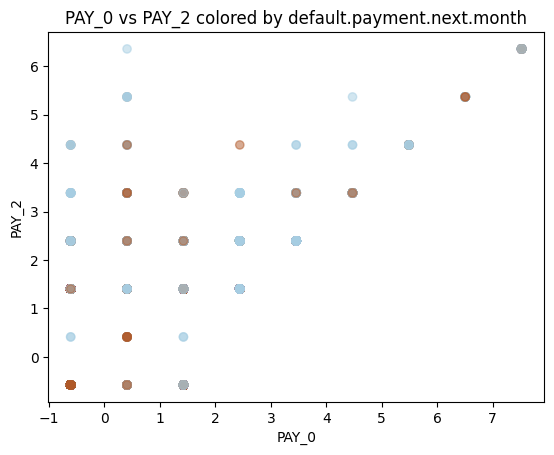

In [16]:
# scatter plot only first two features
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='Paired_r', alpha=0.5)
plt.xlabel('PAY_0')
plt.ylabel('PAY_2')
plt.title('PAY_0 vs PAY_2 colored by default.payment.next.month')
plt.show()

Accuracy: 0.7238991968983661
Confusion Matrix:


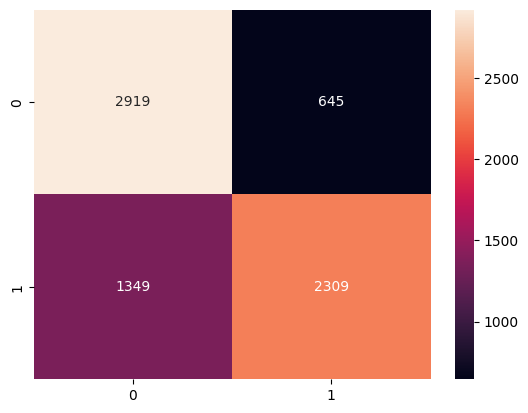

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.82      0.75      3564
           1       0.78      0.63      0.70      3658

    accuracy                           0.72      7222
   macro avg       0.73      0.73      0.72      7222
weighted avg       0.73      0.72      0.72      7222



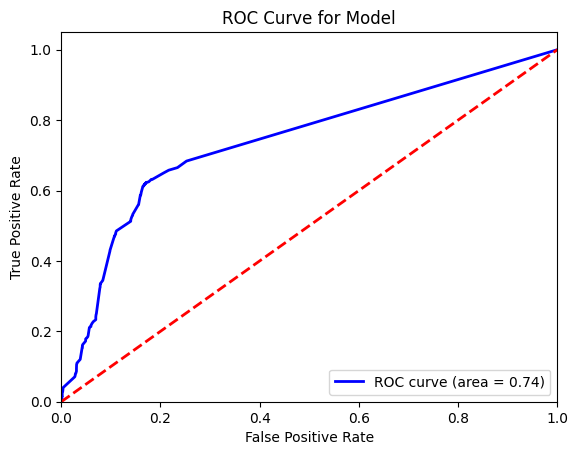

In [19]:
svm_clf = SVC(kernel='rbf', random_state=42)
svm_clf.fit(X_train, y_train)
y_pred = svm_clf.predict(X_test)
y_pred_proba = svm_clf.decision_function(X_test)
helper.evaluate_model(y_test, y_pred)
helper.plot_roc_curve(y_test, y_pred_proba)

In [13]:
print(y_pred_proba[:5])
print(y_pred[:5])

[ 1.00039031 -0.9996253  -0.9996253  -0.99970837 -0.9996253 ]
[1 0 0 0 0]


Accuracy: 0.7244530600941568
Confusion Matrix:


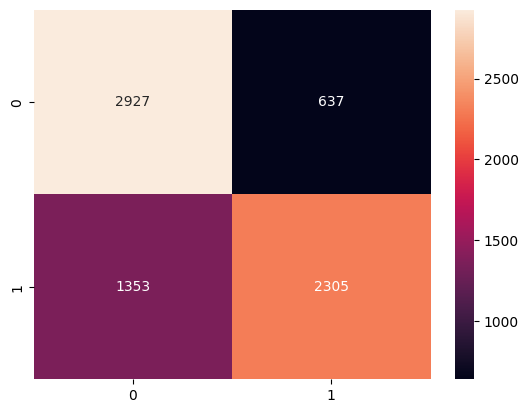

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.82      0.75      3564
           1       0.78      0.63      0.70      3658

    accuracy                           0.72      7222
   macro avg       0.73      0.73      0.72      7222
weighted avg       0.73      0.72      0.72      7222



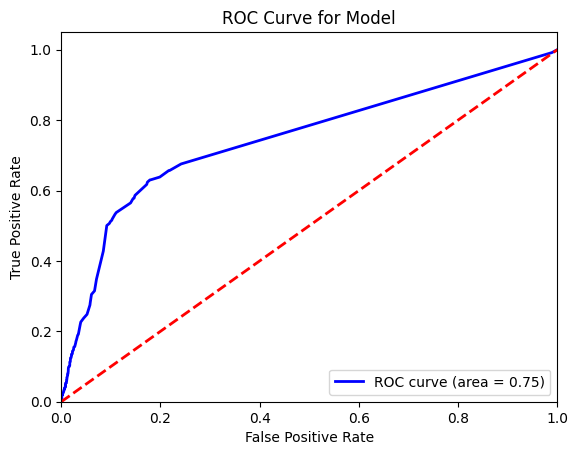

In [22]:
svm_clf = SVC(kernel='poly', degree=2, random_state=42)
svm_clf.fit(X_train, y_train)
y_pred = svm_clf.predict(X_test)
y_pred_proba = svm_clf.decision_function(X_test)
helper.evaluate_model(y_test, y_pred)
helper.plot_roc_curve(y_test, y_pred_proba)

In [4]:
class SVM_Non_Linear_Scratch:
    def __init__(self, kernel='poly', C=1, degree=2, const=1, sigma=0.1, iterations=1000, learning_rate=0.001, batch_size=256, log_interval=100):
        self.X = None
        self.y = None
        self.alpha = None
        self.ones = None
        self.b = 0
        self.C = C
        self.iterations = iterations
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.log_interval = log_interval

        if kernel == 'poly':
            self.kernel = self.polynomial_kernel
            self.degree = degree
            self.const = const
        elif kernel == 'rbf':
            self.kernel = self.gaussian_kernel
            self.sigma = sigma

    def polynomial_kernel(self, X, Z):
        # K(X, Z) = (c + X.Z)^degree
        return (self.const + X.dot(Z.T))**self.degree

    def gaussian_kernel(self, X, Z):
        # K(X, Z) = e^( -(1/ σ2) * ||X-Z||^2 )
        return np.exp(-(1 / self.sigma ** 2) * np.linalg.norm(X[:, np.newaxis] - Z[np.newaxis, :], axis=2) ** 2)

    def decision_function(self, X):
        # ŷ = sign( (αi*yi).K(xi, xi) + b )
        # Compute kernel in chunks to avoid memory issues
        n = self.X.shape[0]
        m = X.shape[0]
        result = np.zeros(m)
        chunk = self.batch_size
        for start in range(0, n, chunk):
            end = min(start + chunk, n)
            K_chunk = self.kernel(self.X[start:end], X)  # (chunk, m)
            result += (self.alpha[start:end] * self.y[start:end]).dot(K_chunk)
        return result + self.b

    def fit(self, X, y):
        y = np.where(y <= 0, -1, 1)
        self.X = X
        self.y = y
        n = X.shape[0]
        self.alpha = np.random.random(n)
        self.b = 0
        losses = []

        for iteration in range(self.iterations):
            # Sample a mini-batch of indices
            batch_idx = np.random.choice(n, size=min(self.batch_size, n), replace=False)

            # Compute kernel between batch and all samples: K(X[batch], X) — shape (batch_size, n)
            # To save memory, compute (yi*yj)*K(xi,xj) only for batch rows
            X_batch = X[batch_idx]
            y_batch = y[batch_idx]

            # kernel_batch: (batch_size, n)
            kernel_batch = self.kernel(X_batch, X)
            # (yi*yj) * K(xi, xj) for batch rows
            kernel_mat_batch = np.outer(y_batch, y) * kernel_batch

            # gradient for batch indices: 1 – kernel_mat_batch.dot(alpha)
            gradient = np.ones(len(batch_idx)) - kernel_mat_batch.dot(self.alpha)

            # α = α + η * gradient (only update batch indices)
            self.alpha[batch_idx] = self.alpha[batch_idx] + self.learning_rate * gradient
            # 0 < α < C
            self.alpha[self.alpha > self.C] = self.C
            self.alpha[self.alpha < 0] = 0

            # Log loss periodically
            if (iteration + 1) % self.log_interval == 0 or iteration == 0:
                # Approximate loss using a sample to avoid full kernel computation
                sample_idx = np.random.choice(n, size=min(self.batch_size, n), replace=False)
                K_sample = self.kernel(X[sample_idx], X[sample_idx])
                alpha_s = self.alpha[sample_idx]
                y_s = y[sample_idx]
                scale = (n / len(sample_idx))
                loss = np.sum(self.alpha) - 0.5 * scale**2 * np.sum(
                    np.outer(alpha_s, alpha_s) * np.outer(y_s, y_s) * K_sample
                )
                losses.append(loss)
                print(f"Iteration {iteration + 1}/{self.iterations} | Approx Loss: {loss:.4f}")

        # for bias, only consider α which 0 < α < C
        # b = avg(0≤αi≤C){ yi – ∑( αj*yj * K(xj, xi) ) }
        index = np.where((self.alpha > 0) & (self.alpha < self.C))[0]
        if len(index) == 0:
            self.b = 0
        else:
            # Compute bias in chunks to save memory
            b_vals = np.zeros(len(index))
            chunk = self.batch_size
            for start in range(0, n, chunk):
                end = min(start + chunk, n)
                K_chunk = self.kernel(X[start:end], X[index])  # (chunk, len(index))
                b_vals += (self.alpha[start:end] * y[start:end]).dot(K_chunk)
            b_vals = y[index] - b_vals
            self.b = np.mean(b_vals)

        return self.alpha, self.b, losses

    def predict(self, X):
        prediction = self.decision_function(X)
        label_signs = np.sign(prediction)
        result = np.where(label_signs <= -1, 0, 1)
        return result

Iteration 1/1000 | Approx Loss: -8583866.5449
Iteration 100/1000 | Approx Loss: -508229.5209
Iteration 200/1000 | Approx Loss: -267223.6974
Iteration 300/1000 | Approx Loss: -527410.2345
Iteration 400/1000 | Approx Loss: -388788.4178
Iteration 500/1000 | Approx Loss: -700603.0472
Iteration 600/1000 | Approx Loss: -287656.5721
Iteration 700/1000 | Approx Loss: -258615.0753
Iteration 800/1000 | Approx Loss: -207640.4859
Iteration 900/1000 | Approx Loss: -141220.5596
Iteration 1000/1000 | Approx Loss: -143786.4353
Accuracy: 0.6752977014677375
Confusion Matrix:


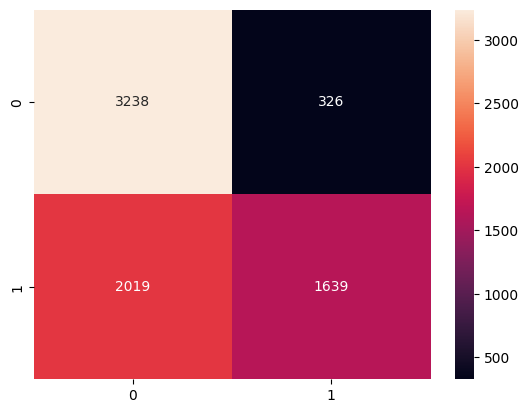

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.91      0.73      3564
           1       0.83      0.45      0.58      3658

    accuracy                           0.68      7222
   macro avg       0.73      0.68      0.66      7222
weighted avg       0.73      0.68      0.66      7222



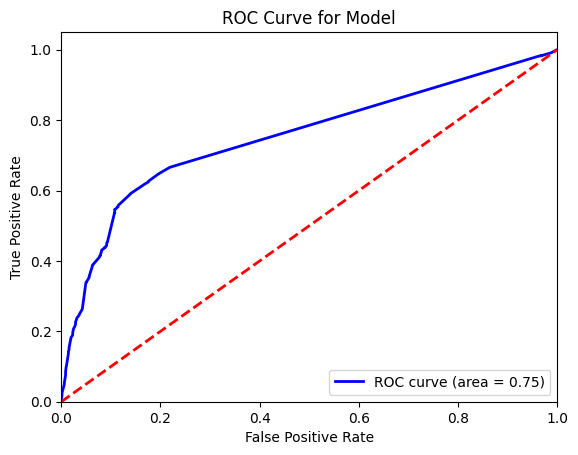

In [5]:
svm_scratch = SVM_Non_Linear_Scratch(kernel='rbf', C=1, sigma=0.1, iterations=1000, learning_rate=0.001, batch_size=256, log_interval=100)
svm_scratch.fit(X_train, y_train)
y_pred_scratch_proba = svm_scratch.decision_function(X_test)
y_pred_scratch = np.where(np.sign(y_pred_scratch_proba) <= -1, 0, 1)
helper.evaluate_model(y_test, y_pred_scratch)
helper.plot_roc_curve(y_test, y_pred_scratch_proba)

Iteration 1/1000 | Approx Loss: -852677543.5253
Iteration 100/1000 | Approx Loss: -40344787.3074
Iteration 200/1000 | Approx Loss: -164376529.1516
Iteration 300/1000 | Approx Loss: -98122830.0438
Iteration 400/1000 | Approx Loss: -20690242.0648
Iteration 500/1000 | Approx Loss: -24982974.8215
Iteration 600/1000 | Approx Loss: -154807026.7137
Iteration 700/1000 | Approx Loss: -34069214.8200
Iteration 800/1000 | Approx Loss: -38357138.2551
Iteration 900/1000 | Approx Loss: -20530092.6305
Iteration 1000/1000 | Approx Loss: -4810824.3623
Accuracy: 0.6762669620603711
Confusion Matrix:


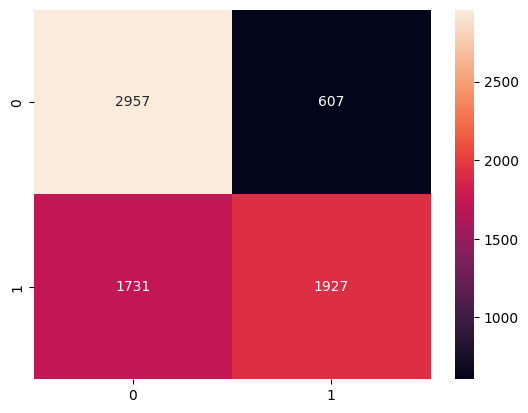

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.83      0.72      3564
           1       0.76      0.53      0.62      3658

    accuracy                           0.68      7222
   macro avg       0.70      0.68      0.67      7222
weighted avg       0.70      0.68      0.67      7222



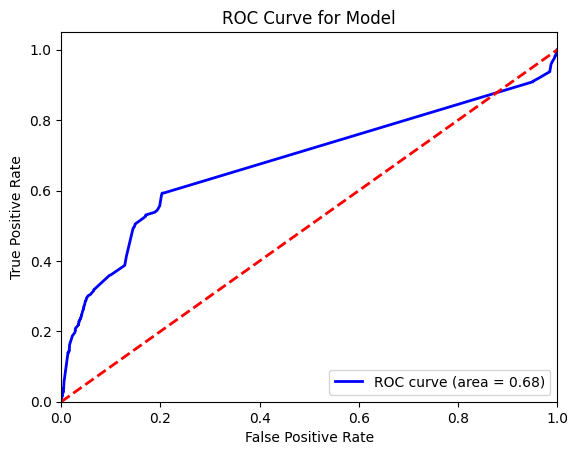

In [6]:
svm_scratch_poly = SVM_Non_Linear_Scratch(kernel='poly', degree=2, const=1, C=1, iterations=1000, learning_rate=0.001, batch_size=256, log_interval=100)
svm_scratch_poly.fit(X_train, y_train)
y_pred_scratch_poly_proba = svm_scratch_poly.decision_function(X_test)
y_pred_scratch_poly = np.where(np.sign(y_pred_scratch_poly_proba) <= -1, 0, 1)
helper.evaluate_model(y_test, y_pred_scratch_poly)
helper.plot_roc_curve(y_test, y_pred_scratch_poly_proba)